# Rabi Oscillation Simulation with Qiskit Dynamics

This notebook demonstrates end-to-end Rabi pulse simulation:
1. Define a single-qubit Hamiltonian
2. Apply a drive pulse (square/Gaussian)
3. Sweep amplitude to observe Rabi oscillations
4. Estimate the π-pulse amplitude

This forms the foundation for Phase 3's `rabi_experiment` tool.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dynamics.rabi import RabiConfig, sweep_rabi, estimate_pi_pulse, simulate_rabi

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Single Rabi Oscillation

Drive a 5 GHz qubit with a square pulse and observe the state population.

In [2]:
cfg = RabiConfig(
    qubit_freq_ghz=5.0,
    amp_range=(0.0, 0.08),
    n_amps=1,
    pulse_duration_ns=200,
    dt_ns=0.5,
    pulse_shape='square',
)

# Single pulse at 0.04 GHz drive amplitude
result = simulate_rabi(0.04, cfg)
print(f'Final P(|1⟩) = {result.final_p1:.4f}')
print(f'Time evolution: {len(result.times_ns)} points over {result.times_ns[-1]:.1f} ns')

Final P(|1⟩) = 0.5728
Time evolution: 401 points over 200.0 ns


## 2. Rabi Sweep — Square Pulse

Sweep drive amplitude and plot P(|1⟩) vs amplitude.

In [3]:
cfg_sweep = RabiConfig(
    qubit_freq_ghz=5.0,
    amp_range=(0.0, 0.08),
    n_amps=50,
    pulse_duration_ns=100,
    dt_ns=0.5,
    pulse_shape='square',
)

sweep = sweep_rabi(cfg_sweep)
print(f'Sweep complete: {len(sweep.amplitudes)} amplitudes')
print(f'P(|1⟩) range: [{sweep.final_populations.min():.3f}, {sweep.final_populations.max():.3f}]')
print(f'π-amplitude: {sweep.pi_amplitude * 1e3:.2f} MHz')

Sweep complete: 50 amplitudes
P(|1⟩) range: [0.000, 1.000]
π-amplitude: 31.02 MHz


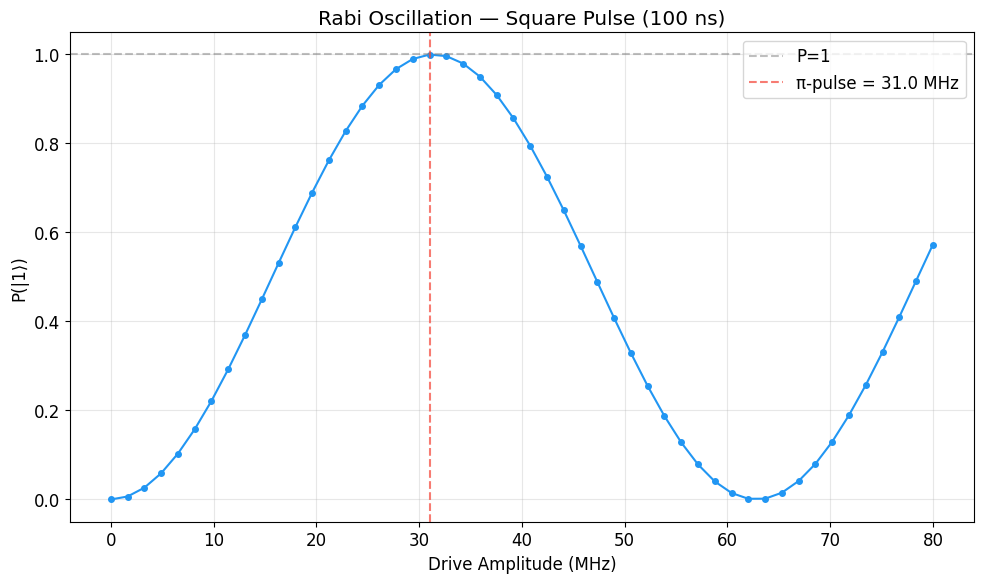

In [4]:
fig, ax = plt.subplots()
ax.plot(sweep.amplitudes * 1e3, sweep.final_populations, 'o-', markersize=4, color='#2196F3')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='P=1')
ax.axvline(x=sweep.pi_amplitude * 1e3, color='#F44336', linestyle='--', alpha=0.7,
           label=f'π-pulse = {sweep.pi_amplitude*1e3:.1f} MHz')
ax.set_xlabel('Drive Amplitude (MHz)')
ax.set_ylabel('P(|1⟩)')
ax.set_title('Rabi Oscillation — Square Pulse (100 ns)')
ax.legend()
plt.tight_layout()
plt.savefig('rabi_square.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rabi Sweep — Gaussian Pulse

Compare with a Gaussian pulse shape.

Gaussian π-amplitude: 53.06 MHz


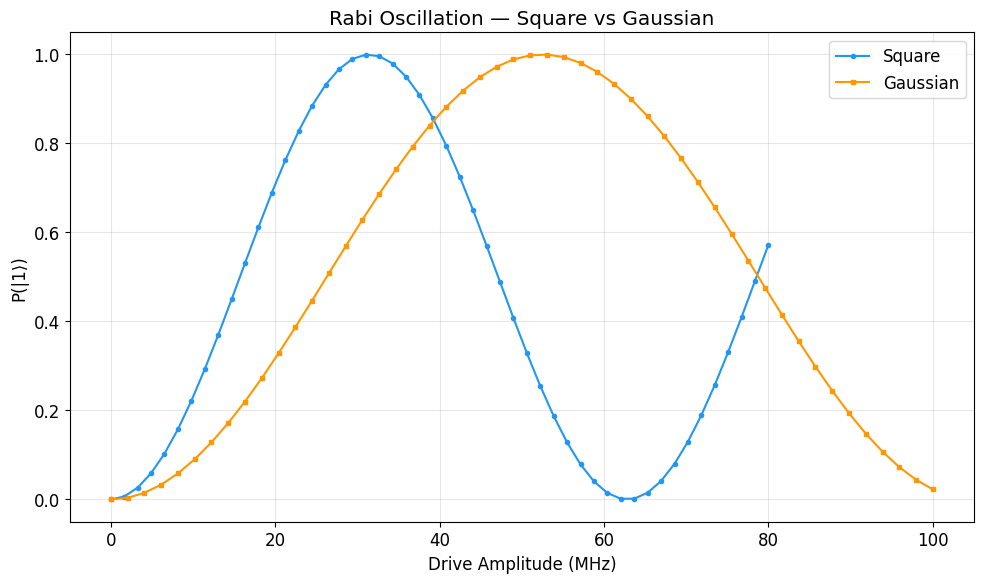

In [5]:
cfg_gauss = RabiConfig(
    qubit_freq_ghz=5.0,
    amp_range=(0.0, 0.10),
    n_amps=50,
    pulse_duration_ns=100,
    dt_ns=0.5,
    pulse_shape='gaussian',
)

sweep_gauss = sweep_rabi(cfg_gauss)
print(f'Gaussian π-amplitude: {sweep_gauss.pi_amplitude * 1e3:.2f} MHz')

fig, ax = plt.subplots()
ax.plot(sweep.amplitudes * 1e3, sweep.final_populations, 'o-', markersize=3,
        color='#2196F3', label='Square')
ax.plot(sweep_gauss.amplitudes * 1e3, sweep_gauss.final_populations, 's-', markersize=3,
        color='#FF9800', label='Gaussian')
ax.set_xlabel('Drive Amplitude (MHz)')
ax.set_ylabel('P(|1⟩)')
ax.set_title('Rabi Oscillation — Square vs Gaussian')
ax.legend()
plt.tight_layout()
plt.savefig('rabi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. π-Pulse Estimation with Refinement

Use coarse sweep + fine zoom to precisely estimate the π-pulse amplitude.

In [6]:
cfg_pi = RabiConfig(
    qubit_freq_ghz=5.0,
    amp_range=(0.0, 0.08),
    n_amps=20,
    pulse_duration_ns=100,
    dt_ns=0.5,
    pulse_shape='square',
)

pi_result = estimate_pi_pulse(cfg_pi, refine=True)
print(f'π-pulse amplitude: {pi_result["pi_amp"] * 1e3:.2f} MHz')
print(f'π-pulse fidelity:  {pi_result["pi_fidelity"]:.4f}')
print(f'π/2 amplitude:     {pi_result["half_pi_amp"] * 1e3:.2f} MHz')
print(f'Coarse sweep: {len(pi_result["coarse_sweep"].amplitudes)} points')
if pi_result['fine_sweep']:
    print(f'Fine sweep:   {len(pi_result["fine_sweep"].amplitudes)} points')

π-pulse amplitude: 31.36 MHz
π-pulse fidelity:  1.0000
π/2 amplitude:     15.68 MHz
Coarse sweep: 20 points
Fine sweep:   51 points


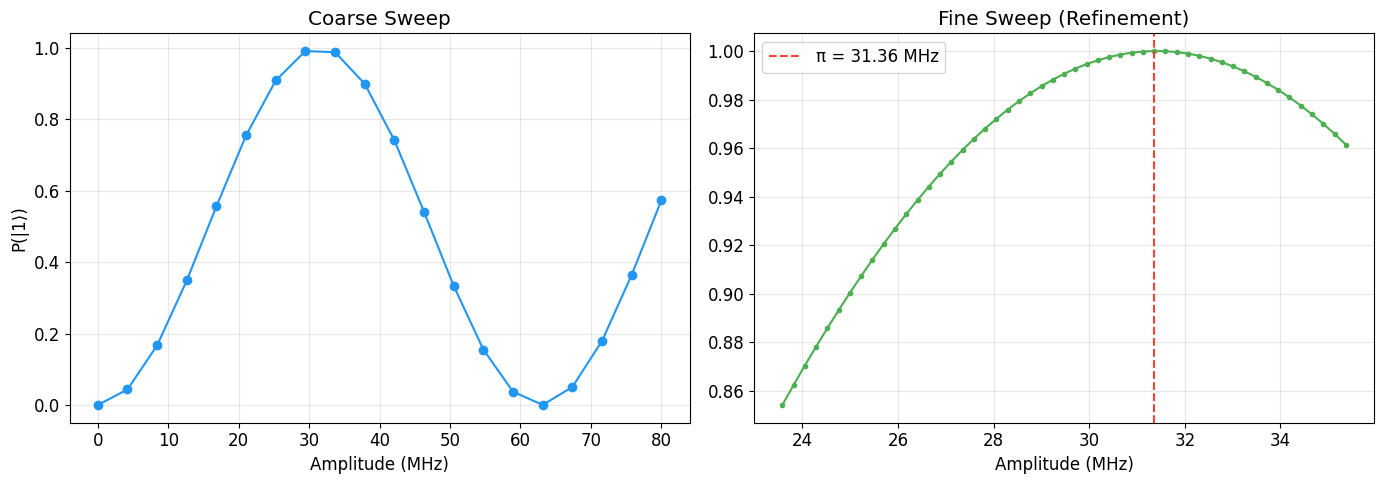

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coarse
cs = pi_result['coarse_sweep']
ax1.plot(cs.amplitudes * 1e3, cs.final_populations, 'o-', color='#2196F3')
ax1.set_title('Coarse Sweep')
ax1.set_xlabel('Amplitude (MHz)')
ax1.set_ylabel('P(|1⟩)')

# Fine
if pi_result['fine_sweep']:
    fs = pi_result['fine_sweep']
    ax2.plot(fs.amplitudes * 1e3, fs.final_populations, 'o-', color='#4CAF50', markersize=3)
    ax2.axvline(x=pi_result['pi_amp'] * 1e3, color='#F44336', linestyle='--',
               label=f'π = {pi_result["pi_amp"]*1e3:.2f} MHz')
    ax2.set_title('Fine Sweep (Refinement)')
    ax2.set_xlabel('Amplitude (MHz)')
    ax2.legend()

plt.tight_layout()
plt.savefig('rabi_pi_estimation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Varying Pulse Duration

Show how the Rabi frequency depends on pulse duration.

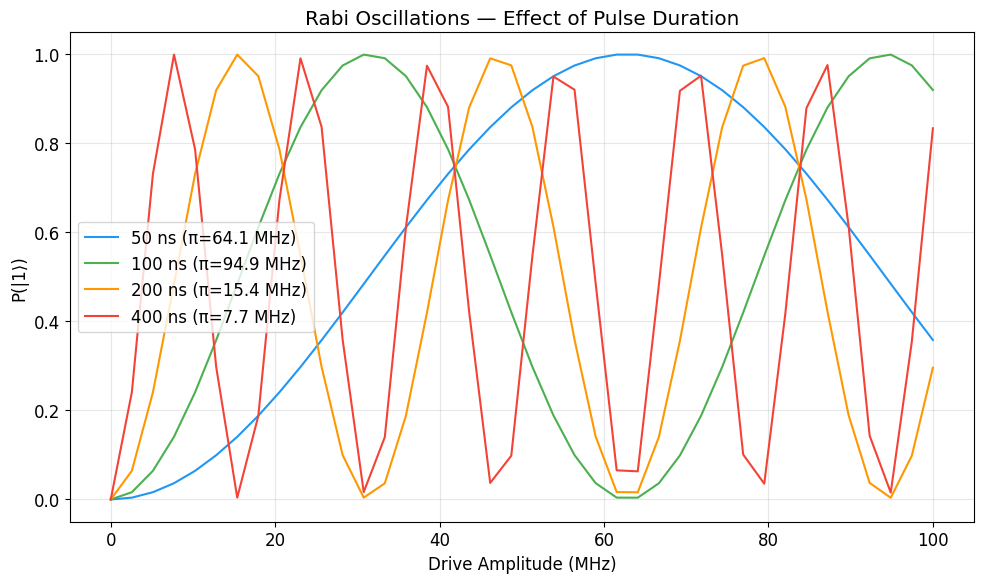


Notebook complete. All Qiskit Dynamics Rabi simulations verified.


In [8]:
durations = [50, 100, 200, 400]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for dur, color in zip(durations, colors):
    cfg_d = RabiConfig(
        qubit_freq_ghz=5.0,
        amp_range=(0.0, 0.10),
        n_amps=40,
        pulse_duration_ns=dur,
        dt_ns=0.5,
        pulse_shape='square',
    )
    s = sweep_rabi(cfg_d)
    ax.plot(s.amplitudes * 1e3, s.final_populations, '-', color=color,
            label=f'{dur} ns (π={s.pi_amplitude*1e3:.1f} MHz)')

ax.set_xlabel('Drive Amplitude (MHz)')
ax.set_ylabel('P(|1⟩)')
ax.set_title('Rabi Oscillations — Effect of Pulse Duration')
ax.legend()
plt.tight_layout()
plt.savefig('rabi_durations.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNotebook complete. All Qiskit Dynamics Rabi simulations verified.')